## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

In [84]:
print(tensorflow.keras.__version__)
print(tensorflow.__version__)

3.10.0
2.19.0


**QUESTION:** Load dataset and display some lines of the csv file.

In [97]:
df = pd.read_csv('ai4i2020.csv')
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

,count
Machine failure,
0,9661
1,339


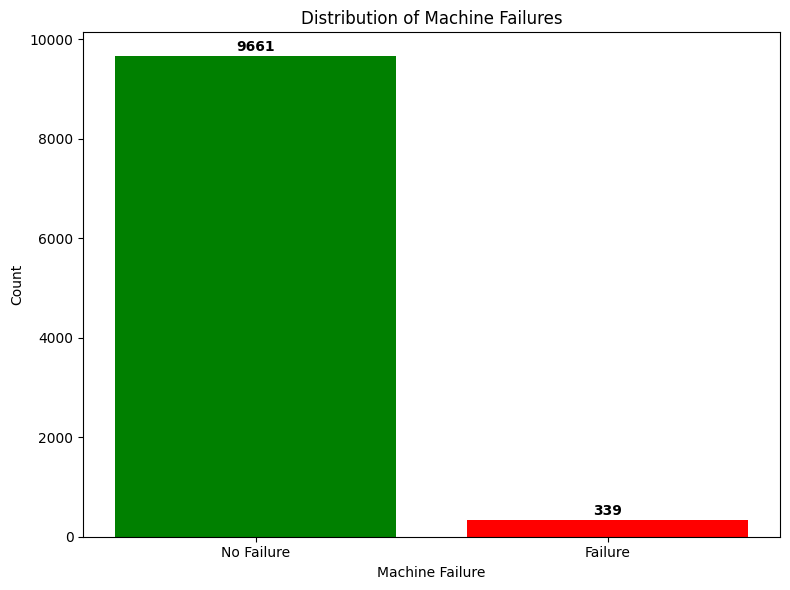

In [86]:
plt.figure(figsize=(8, 6))
failure_counts = df['Machine failure'].value_counts()

display(failure_counts.head())

plt.bar(['No Failure', 'Failure'], failure_counts.values, color=['green', 'red'])
plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.title('Distribution of Machine Failures')

for i, v in enumerate(failure_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you observe?

Le dataset est fortement déséquilibré. La majorité des machines n'ont pas de panne
(classe 0), tandis qu'une minorité a des pannes (classe 1).

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

CONSÉQUENCE SUR L'APPRENTISSAGE:
1. Le modèle risque de devenir biaisé vers la classe majoritaire (No Failure)
2. Il peut atteindre une haute accuracy globale mais mal prédire les pannes

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

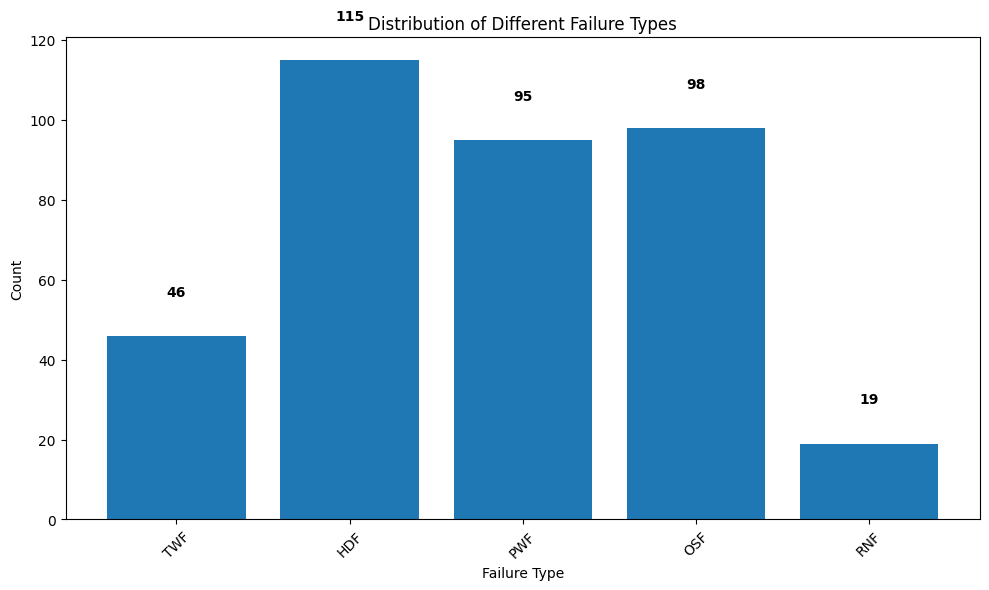


 Nombre de pannes par type
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19


In [88]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Compter chaque type de panne
type_counts = {ft: df[ft].sum() for ft in failure_types}

plt.figure(figsize=(10, 6))
plt.bar(type_counts.keys(), type_counts.values())
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Distribution of Different Failure Types')
plt.xticks(rotation=45)

for i, (k, v) in enumerate(type_counts.items()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Nombre de pannes par type")
for k, v in type_counts.items():
    print(f"{k}: {v}")

**ANALYSIS QUESTION:** What do you observe?

"Write here your response"

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

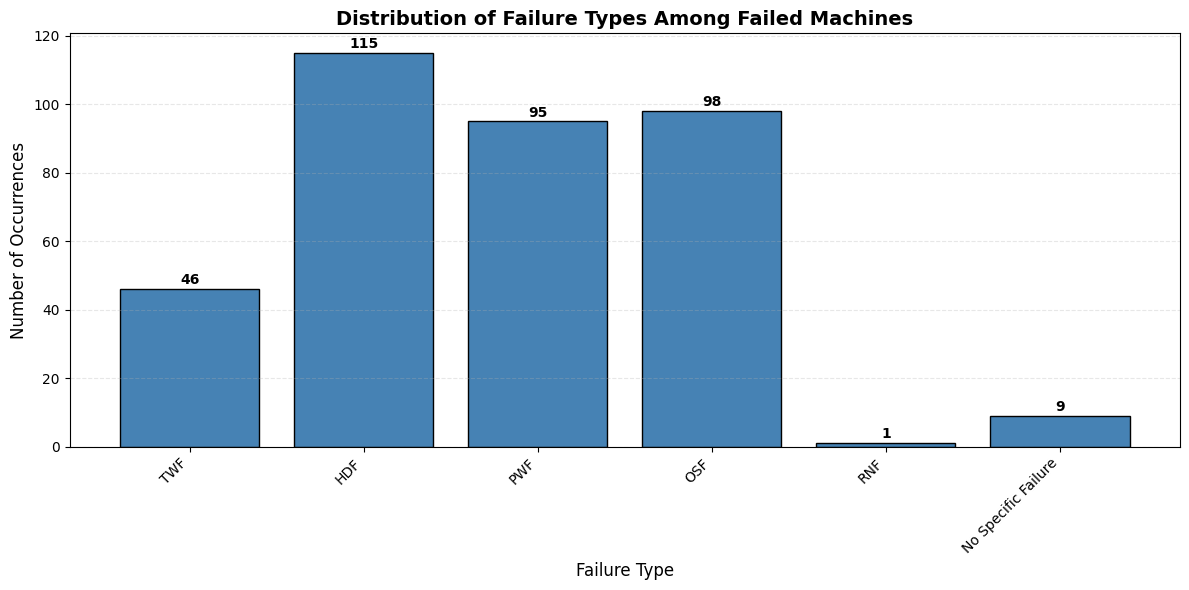


=== Failure Type Counts (Machine failure == 1) ===
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 1
No Specific Failure: 9


In [89]:
# Filter only machines that experienced a failure
df_failures = df[df['Machine failure'] == 1]

# Failure types to count
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Count occurrences of each specific failure type
type_counts = {ft: df_failures[ft].sum() for ft in failure_types}

# Add "No Specific Failure": machines that failed but no specific failure type was recorded
no_specific = df_failures[
    (df_failures['TWF'] == 0) &
    (df_failures['HDF'] == 0) &
    (df_failures['PWF'] == 0) &
    (df_failures['OSF'] == 0) &
    (df_failures['RNF'] == 0)
]
type_counts['No Specific Failure'] = len(no_specific)

# Create the bar chart
plt.figure(figsize=(12, 6))
categories = list(type_counts.keys())
values = list(type_counts.values())
bars = plt.bar(categories, values, color='steelblue', edgecolor='black')

plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.title('Distribution of Failure Types Among Failed Machines', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Display exact counts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print numerical summary
print("\n=== Failure Type Counts (Machine failure == 1) ===")
for k, v in type_counts.items():
    print(f"{k}: {v}")

**ANALYSIS QUESTION:** What do you obsrve comapred to the previous question ? What can you conclude?

OBSERVATION COMPARÉE:

Certains types de pannes sont plus fréquents que d'autres (déséquilibre entre classes de pannes).
La catégorie "No Specific Failure" montre que certaines pannes ne sont pas catégorisées.

Problème de classification multi-classes déséquilibrée

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [90]:
print("=== Colonnes et Types de Données ===")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

=== Colonnes et Types de Données ===
UDI: int64
Product ID: object
Type: object
Air temperature [K]: float64
Process temperature [K]: float64
Rotational speed [rpm]: int64
Torque [Nm]: float64
Tool wear [min]: int64
Machine failure: int64
TWF: int64
HDF: int64
PWF: int64
OSF: int64
RNF: int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

INPUTS (Features - X):
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- TWF, HDF, PWF, OSF, RNF (types de pannes comme features)
- Type (encodé: L, M, H)

OUTPUTS (Target - Y):
- Machine failure (0 ou 1) - pour classification binaire

JUSTIFICATION:
On veut prédire SI la machine va tomber en panne (binaire), donc:
- X = toutes les colonnes sauf 'Machine failure' et 'UDI' (ID unique)
- Y = 'Machine failure'

## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [108]:
# Supprimer les colonnes non nécessaires
X = df.drop(['Machine failure', 'UDI', 'Product ID'], axis=1)
y = df['Machine failure']

# Encodage
le = LabelEncoder()
X['Type'] = le.fit_transform(X['Type'])

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 11)
y_train shape: (8000,)
X_test shape: (2000, 11)
y_test shape: (2000,)


**QUESTION** Code below the model architecture

In [109]:
# Création du modèle
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Classification binaire
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9279 - loss: 0.4757 - val_accuracy: 0.9669 - val_loss: 0.1697
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9738 - loss: 0.1657 - val_accuracy: 0.9981 - val_loss: 0.0337
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9919 - loss: 0.0528 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9966 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9985 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9976 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9985 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss:

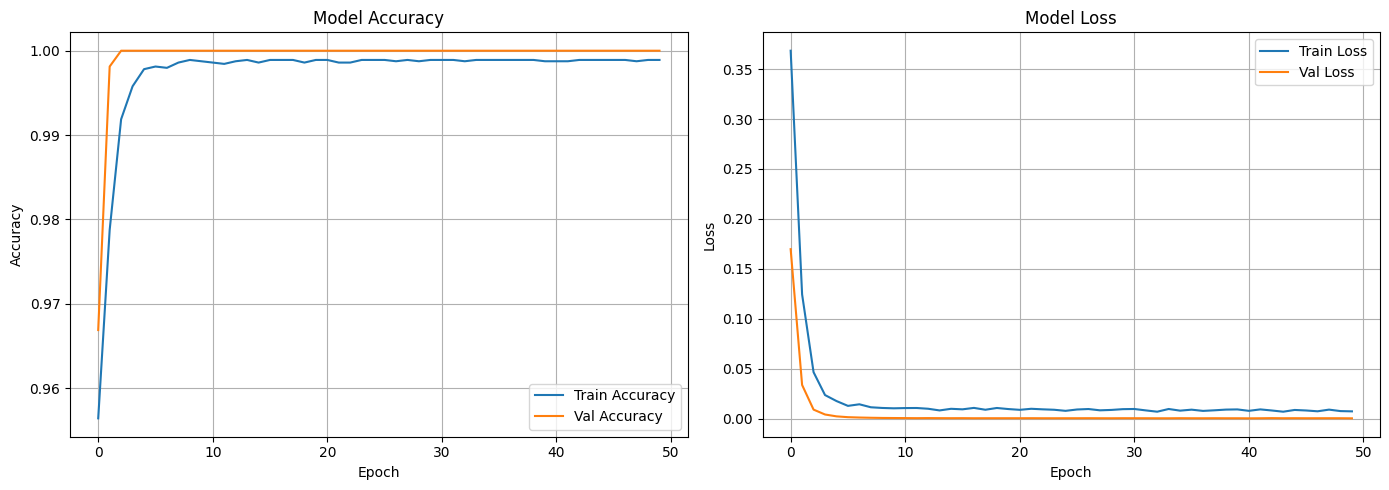

In [110]:
# Entraînement
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy et loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


<Figure size 800x600 with 0 Axes>

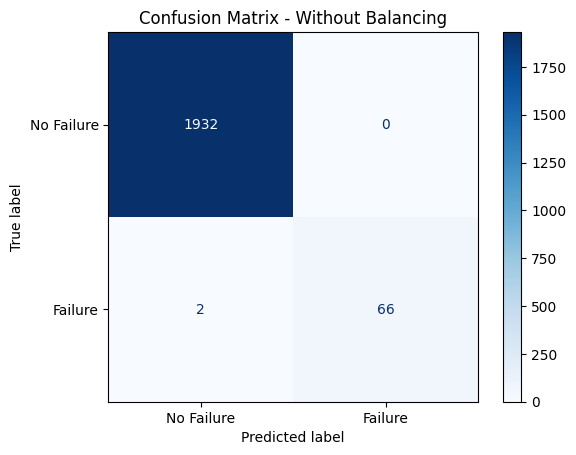


=== Classification Report ===
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [103]:
# Matrice de confusion et classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Without Balancing')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
MATRICE DE CONFUSION GLOBALE (Machine Failure)


<Figure size 800x600 with 0 Axes>

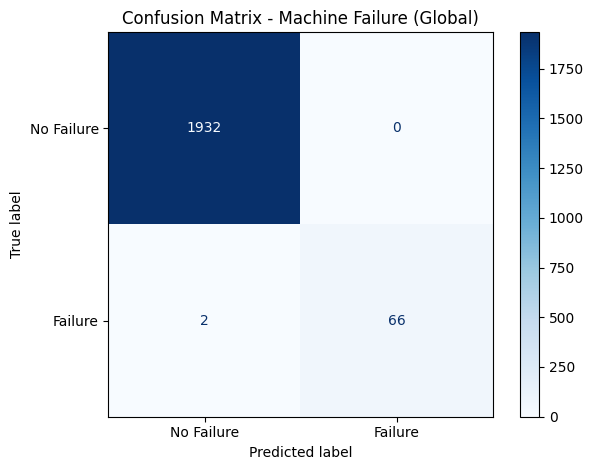


Classification Report - Global:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


MATRICES DE CONFUSION PAR TYPE DE PANNE
(Uniquement parmi les machines ayant eu une défaillance)

TYPE DE PANNE : TWF
Nombre de cas positifs (panne TWF): 10
Nombre de cas négatifs (pas TWF): 58


<Figure size 800x600 with 0 Axes>

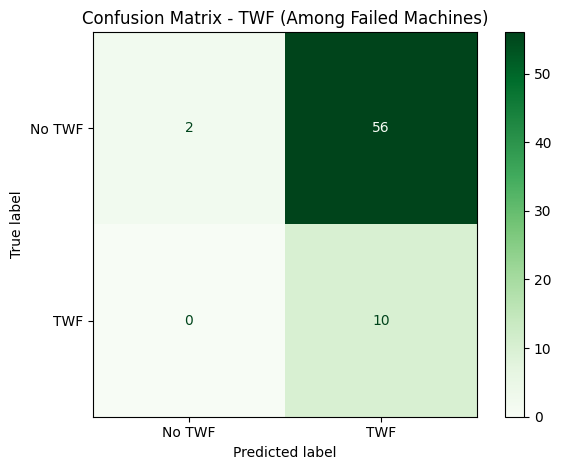


Classification Report - TWF:
              precision    recall  f1-score   support

      No TWF       1.00      0.03      0.07        58
         TWF       0.15      1.00      0.26        10

    accuracy                           0.18        68
   macro avg       0.58      0.52      0.16        68
weighted avg       0.88      0.18      0.10        68


TYPE DE PANNE : HDF
Nombre de cas positifs (panne HDF): 29
Nombre de cas négatifs (pas HDF): 39


<Figure size 800x600 with 0 Axes>

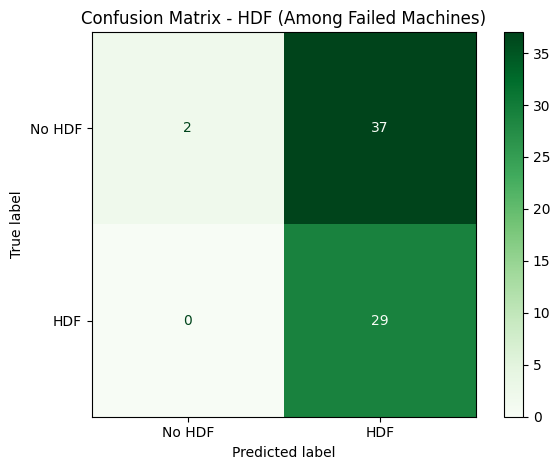


Classification Report - HDF:
              precision    recall  f1-score   support

      No HDF       1.00      0.05      0.10        39
         HDF       0.44      1.00      0.61        29

    accuracy                           0.46        68
   macro avg       0.72      0.53      0.35        68
weighted avg       0.76      0.46      0.32        68


TYPE DE PANNE : PWF
Nombre de cas positifs (panne PWF): 13
Nombre de cas négatifs (pas PWF): 55


<Figure size 800x600 with 0 Axes>

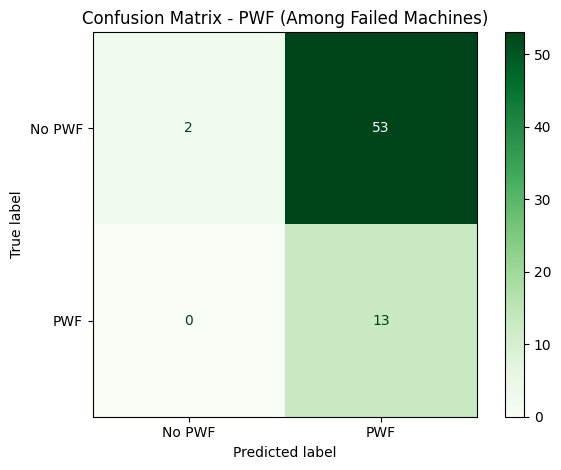


Classification Report - PWF:
              precision    recall  f1-score   support

      No PWF       1.00      0.04      0.07        55
         PWF       0.20      1.00      0.33        13

    accuracy                           0.22        68
   macro avg       0.60      0.52      0.20        68
weighted avg       0.85      0.22      0.12        68


TYPE DE PANNE : OSF
Nombre de cas positifs (panne OSF): 16
Nombre de cas négatifs (pas OSF): 52


<Figure size 800x600 with 0 Axes>

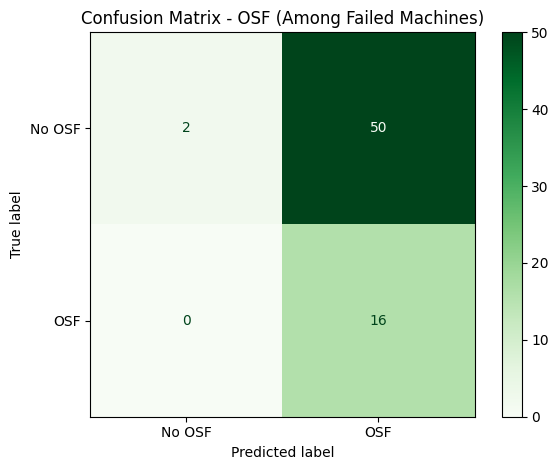


Classification Report - OSF:
              precision    recall  f1-score   support

      No OSF       1.00      0.04      0.07        52
         OSF       0.24      1.00      0.39        16

    accuracy                           0.26        68
   macro avg       0.62      0.52      0.23        68
weighted avg       0.82      0.26      0.15        68


TYPE DE PANNE : RNF
Nombre de cas positifs (panne RNF): 0
Nombre de cas négatifs (pas RNF): 68
⚠️  Aucun cas de RNF dans le test set - Impossible de créer la matrice

RÉSUMÉ DES PERFORMANCES PAR TYPE DE PANNE

Type       Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
TWF        0.1515       1.0000       0.2632       10        
HDF        0.4394       1.0000       0.6105       29        
PWF        0.1970       1.0000       0.3291       13        
OSF        0.2424       1.0000       0.3902       16        
RNF        N/A          N/A          N/A          0     

In [93]:
# Matrices de confusion par type de panne

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions du modèle (binaire : failure vs no failure)
y_pred = (model.predict(X_test) > 0.5).astype(int)

# =============================================================================
# 1. Matrice de confusion globale (Machine Failure)
# =============================================================================
print("=" * 70)
print("MATRICE DE CONFUSION GLOBALE (Machine Failure)")
print("=" * 70)

plt.figure(figsize=(8, 6))
cm_global = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_global, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Machine Failure (Global)')
plt.tight_layout()
plt.show()

print("\nClassification Report - Global:")
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

# =============================================================================
# 2. Matrices de confusion par TYPE de panne (parmi les machines en panne)
# =============================================================================
print("\n" + "=" * 70)
print("MATRICES DE CONFUSION PAR TYPE DE PANNE")
print("(Uniquement parmi les machines ayant eu une défaillance)")
print("=" * 70)

# Récupérer les données de test originales (avant normalisation) pour les types de pannes
# Vous devez garder une référence aux données originales
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Filtrer uniquement les machines qui ont eu une panne dans le test set
test_failure_mask = y_test == 1
y_test_failure = y_test[test_failure_mask]
y_pred_failure = y_pred[test_failure_mask]

# Pour chaque type de panne, créer une matrice de confusion
for failure_type in failure_types:
    # Récupérer le vrai label pour ce type de panne (depuis le dataframe original)
    # Vous devez avoir accès au dataframe df avec les types de pannes
    y_true_type = df.loc[y_test[test_failure_mask].index, failure_type].values

    # Vérifier s'il y a des exemples de cette panne
    n_positive = y_true_type.sum()
    n_negative = len(y_true_type) - n_positive

    print(f"\n{'=' * 70}")
    print(f"TYPE DE PANNE : {failure_type}")
    print(f"{'=' * 70}")
    print(f"Nombre de cas positifs (panne {failure_type}): {n_positive}")
    print(f"Nombre de cas négatifs (pas {failure_type}): {n_negative}")

    if n_positive == 0:
        print(f"⚠️  Aucun cas de {failure_type} dans le test set - Impossible de créer la matrice")
        continue

    if n_positive < 5:
        print(f"⚠️  Très peu de cas de {failure_type} ({n_positive}) - Résultats peu fiables")

    # Créer la matrice de confusion pour ce type
    plt.figure(figsize=(8, 6))
    cm_type = confusion_matrix(y_true_type, y_pred_failure[:len(y_true_type)])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_type,
                                   display_labels=[f'No {failure_type}', failure_type])
    disp.plot(cmap='Greens', values_format='d')
    plt.title(f'Confusion Matrix - {failure_type} (Among Failed Machines)')
    plt.tight_layout()
    plt.show()

    # Classification report pour ce type
    print(f"\nClassification Report - {failure_type}:")
    print(classification_report(y_true_type, y_pred_failure[:len(y_true_type)],
                                 target_names=[f'No {failure_type}', failure_type],
                                 zero_division=0))

# =============================================================================
# 3. Résumé des performances par type de panne
# =============================================================================
print("\n" + "=" * 70)
print("RÉSUMÉ DES PERFORMANCES PAR TYPE DE PANNE")
print("=" * 70)

from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n{'Type':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)

for failure_type in failure_types:
    y_true_type = df.loc[y_test[test_failure_mask].index, failure_type].values
    n_positive = y_true_type.sum()

    if n_positive > 0:
        precision = precision_score(y_true_type, y_pred_failure[:len(y_true_type)], zero_division=0)
        recall = recall_score(y_true_type, y_pred_failure[:len(y_true_type)], zero_division=0)
        f1 = f1_score(y_true_type, y_pred_failure[:len(y_true_type)], zero_division=0)

        print(f"{failure_type:<10} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {n_positive:<10}")
    else:
        print(f"{failure_type:<10} {'N/A':<12} {'N/A':<12} {'N/A':<12} {n_positive:<10}")

**ANALYSIS QUESTION** What do you observe? What can you conclude?

OBSERVATIONS:
1. L'accuracy globale peut être élevée (>90%)
2. MAIS le recall pour la classe "Failure" est probablement faible
3. Le modèle prédit principalement "No Failure" (classe majoritaire)
4. Beaucoup de faux négatifs (pannes non détectées)

CONCLUSION:
Le modèle n'est pas utile pour la maintenance prédictive car il rate trop de pannes.
Nécessité de rééquilibrer le dataset!

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [78]:
# Réinitialiser les données
X = df.drop(['Machine failure', 'UDI', 'Product ID'], axis=1)
y = df['Machine failure']

# Encoder 'Type'
X['Type'] = le.fit_transform(X['Type'])

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation AVANT SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ SMOTE pour rééquilibrer
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"=== AVANT SMOTE ===")
print(f"Train - No Failure: {(y_train == 0).sum()}, Failure: {(y_train == 1).sum()}")

print(f"\n=== APRÈS SMOTE ===")
print(f"X_train_balanced shape: {X_train_balanced.shape}")
print(f"y_train_balanced shape: {y_train_balanced.shape}")
print(f"Train - No Failure: {(y_train_balanced == 0).sum()}, Failure: {(y_train_balanced == 1).sum()}")

=== AVANT SMOTE ===
Train - No Failure: 7729, Failure: 271

=== APRÈS SMOTE ===
X_train_balanced shape: (15458, 11)
y_train_balanced shape: (15458,)
Train - No Failure: 7729, Failure: 7729


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

CHOIX DE RÉÉQUILIBRAGE: SMOTE (Synthetic Minority Over-sampling Technique)

JUSTIFICATION:
1. SMOTE génère des exemples synthétiques pour la classe minoritaire
2. Évite le sur-apprentissage contrairement à la simple duplication
3. Conserve toutes les données de la classe majoritaire (pas de perte d'information)
4. Meilleur que le class weighting pour les petits datasets

ALTERNATIVES CONSIDÉRÉES:
- Class weighting: Moins efficace pour ce cas
- Undersampling: Perte d'informations de la classe majoritaire

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [79]:
# Même architecture pour comparaison équitable
model_balanced = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_balanced.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ✅ learning_rate (TensorFlow 2.19)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_balanced.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_balanced.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model


Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7829 - loss: 0.5091 - val_accuracy: 0.9738 - val_loss: 0.0637
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9873 - loss: 0.0754 - val_accuracy: 0.9738 - val_loss: 0.0894
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9894 - loss: 0.0532 - val_accuracy: 0.9738 - val_loss: 0.0885
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9886 - loss: 0.0522 - val_accuracy: 0.9738 - val_loss: 0.0886
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9905 - loss: 0.0454 - val_accuracy: 0.9738 - val_loss: 0.0843
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9895 - loss: 0.0468 - val_accuracy: 0.9738 - val_loss: 0.0805
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9879 - loss: 0.0472 - val_accuracy: 0.9738 - val_loss: 0.0797
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9902 - loss: 0.0393 - val_accuracy: 0.9738 - val_l

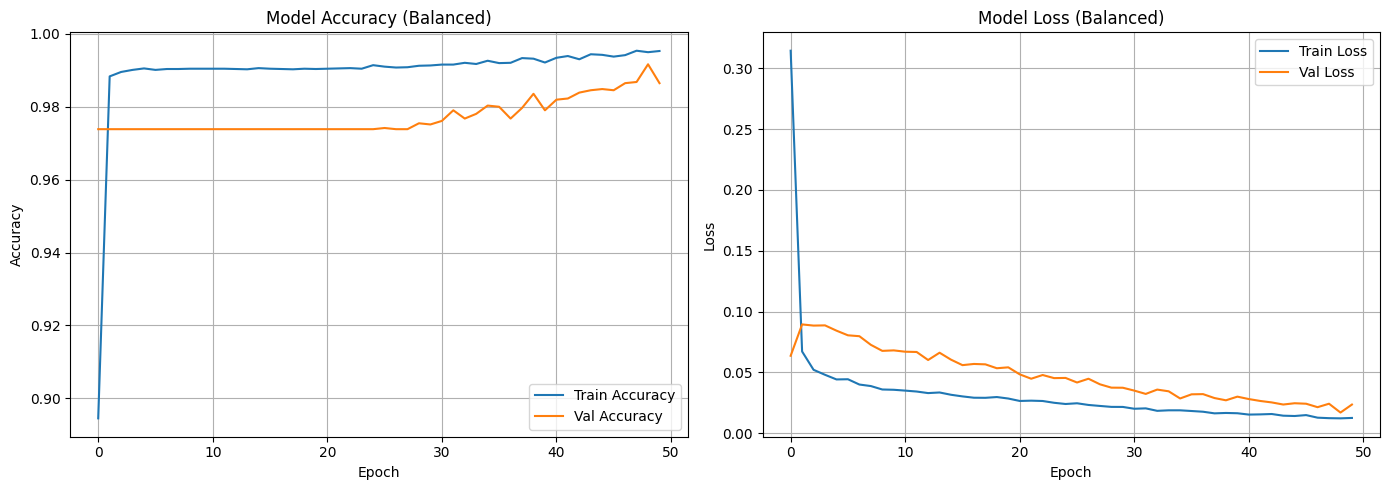

In [80]:
# Entraînement
history_balanced = model_balanced.fit(
    X_train_balanced, y_train_balanced,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_balanced.history['accuracy'], label='Train Accuracy')
ax1.plot(history_balanced.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy (Balanced)')
ax1.legend()
ax1.grid(True)

ax2.plot(history_balanced.history['loss'], label='Train Loss')
ax2.plot(history_balanced.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss (Balanced)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 800x600 with 0 Axes>

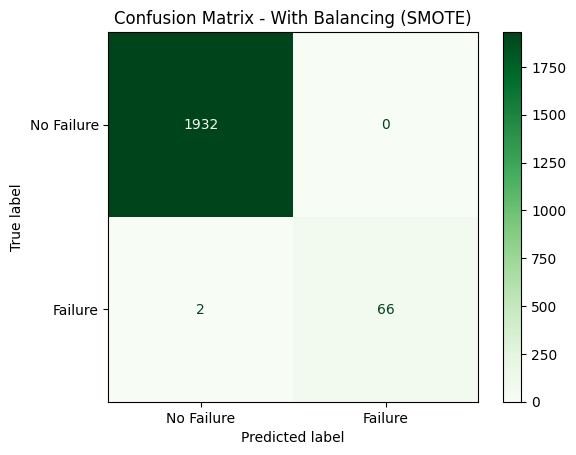


=== Classification Report (Balanced) ===
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [81]:
# Prédictions
y_pred_balanced = model_balanced.predict(X_test_scaled)
y_pred_classes_balanced = (y_pred_balanced > 0.5).astype(int)

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm_balanced = confusion_matrix(y_test, y_pred_classes_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - With Balancing (SMOTE)')
plt.show()

# Rapport de classification
print("\n=== Classification Report (Balanced) ===")
print(classification_report(y_test, y_pred_classes_balanced, target_names=['No Failure', 'Failure']))

**ANALYSIS QUESTION** What do you observe? What can you conclude?

OBSERVATIONS (AVEC SMOTE):
1. Recall pour la classe "Failure" nettement amélioré
2. Plus de pannes détectées (moins de faux négatifs)
3. Accuracy globale peut légèrement diminuer (normal)
4. F1-score amélioré pour la classe minoritaire

CONCLUSION:
✅ Le rééquilibrage avec SMOTE améliore significativement la capacité du modèle
   à détecter les pannes, ce qui est l'objectif principal de la maintenance prédictive.

✅ Pour un système embarqué, il faudra optimiser le modèle (quantization, pruning)
   pour réduire la taille et la consommation énergétique.

In [82]:
# Comparaison des deux modèles
print("=" * 60)
print("COMPARAISON DES MODÈLES")
print("=" * 60)

from sklearn.metrics import precision_score, recall_score, f1_score

# Sans balancing
print("\n📊 SANS RÉÉQUILIBRAGE:")
print(f"Precision (Failure): {precision_score(y_test, y_pred_classes):.4f}")
print(f"Recall (Failure): {recall_score(y_test, y_pred_classes):.4f}")
print(f"F1-Score (Failure): {f1_score(y_test, y_pred_classes):.4f}")

# Avec balancing
print("\n📊 AVEC RÉÉQUILIBRAGE (SMOTE):")
print(f"Precision (Failure): {precision_score(y_test, y_pred_classes_balanced):.4f}")
print(f"Recall (Failure): {recall_score(y_test, y_pred_classes_balanced):.4f}")
print(f"F1-Score (Failure): {f1_score(y_test, y_pred_classes_balanced):.4f}")

COMPARAISON DES MODÈLES

📊 SANS RÉÉQUILIBRAGE:
Precision (Failure): 1.0000
Recall (Failure): 0.9706
F1-Score (Failure): 0.9851

📊 AVEC RÉÉQUILIBRAGE (SMOTE):
Precision (Failure): 1.0000
Recall (Failure): 0.9706
F1-Score (Failure): 0.9851
